# 3 - Dissonance + Chromaticism

## Imports

In [8]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [10]:
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21

import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import intervalanalysis_utils as ia

## Load Data

In [11]:
metadata = g.load_metadata()
metadata = g.load_keys(metadata)

In [12]:
major_metadata = metadata[metadata['key'].str.contains('major', na=False)]
minor_metadata = metadata[metadata['key'].str.contains('minor', na=False)]

## In-Label Dissonance

In [15]:
ILC_major_raw = g.load_labels(major_metadata)
ILC_minor_raw = g.load_labels(minor_metadata)

In [16]:
ILC_major = ILC_major_raw.copy()
ILC_minor = ILC_minor_raw.copy()

ILC_major['dissonance'] = ILC_major['label'].apply(ia.label_to_dissonance)

ILC_major['dissonance'] = ILC_major['dissonance'] * ILC_major['duration_qb']

identifier = ['artist', 'workTitle', 'recording_year']
ILC_major = ILC_major.groupby(by=identifier, as_index=False)[['dissonance', 'duration_qb']].sum()
ILC_major['dissonance'] = ILC_major['dissonance'] / ILC_major['duration_qb']

ILC_minor['dissonance'] = ILC_minor['label'].apply(ia.label_to_dissonance)

ILC_minor['dissonance'] = ILC_minor['dissonance'] * ILC_minor['duration_qb']

identifier = ['artist', 'workTitle', 'recording_year']
ILC_minor = ILC_minor.groupby(by=identifier, as_index=False)[['dissonance', 'duration_qb']].sum()
ILC_minor['dissonance'] = ILC_minor['dissonance'] / ILC_minor['duration_qb']


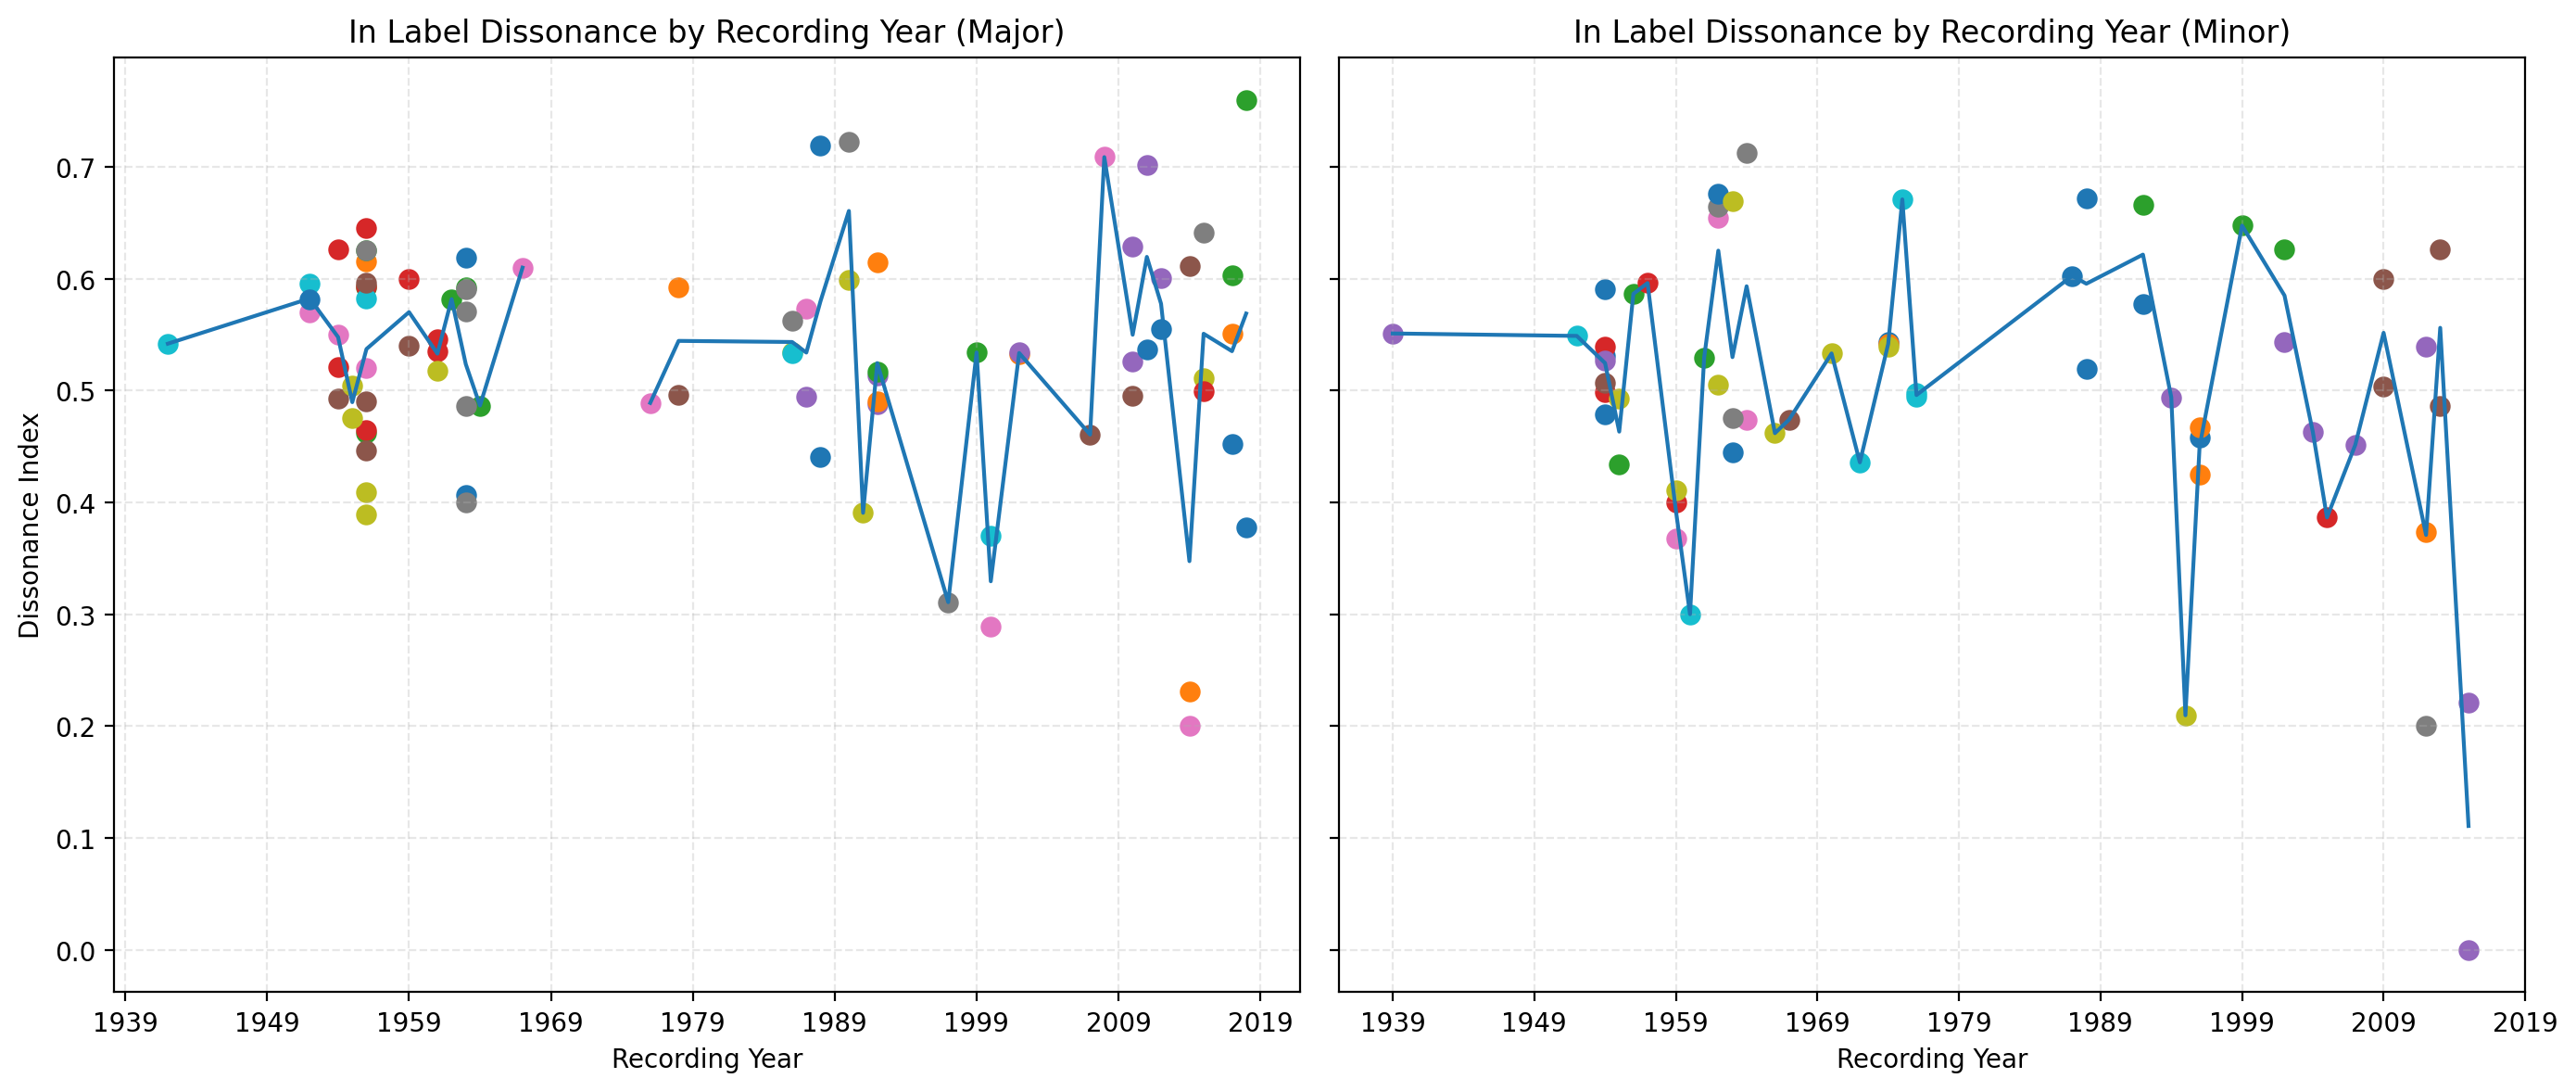

In [17]:
# Ensure recording_year is numeric
ILC_major['recording_year'] = pd.to_numeric(ILC_major['recording_year'], errors='coerce')
ILC_minor['recording_year'] = pd.to_numeric(ILC_minor['recording_year'], errors='coerce')

# Find combined min and max year to keep axes consistent
min_year = min(ILC_major['recording_year'].min(), ILC_minor['recording_year'].min())
max_year = max(ILC_major['recording_year'].max(), ILC_minor['recording_year'].max())

ticks = np.arange(min_year, max_year + 10, 10)

artists = np.unique(np.concatenate([ILC_major['artist'].unique(), ILC_minor['artist'].unique()]))
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot major
for i, artist in enumerate(artists):
    subset = ILC_major[ILC_major['artist'] == artist]
    axes[0].scatter(subset['recording_year'], subset['dissonance'],
                    label=artist, color=colors[i % len(colors)], s=50)

axes[0].plot(ILC_major.groupby(by='recording_year', as_index=False)['dissonance'].mean()['recording_year'], 
             ILC_major.groupby(by='recording_year', as_index=False)['dissonance'].mean()['dissonance'])
axes[0].set_title('In Label Dissonance by Recording Year (Major)')
axes[0].set_xlabel('Recording Year')
axes[0].set_ylabel('Dissonance Index')
axes[0].set_xticks(ticks)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Plot minor
for i, artist in enumerate(artists):
    subset = ILC_minor[ILC_minor['artist'] == artist]
    axes[1].scatter(subset['recording_year'], subset['dissonance'],
                    label=artist, color=colors[i % len(colors)], s=50)

axes[1].plot(ILC_minor.groupby(by='recording_year', as_index=False)['dissonance'].mean()['recording_year'], 
             ILC_minor.groupby(by='recording_year', as_index=False)['dissonance'].mean()['dissonance'])
axes[1].set_title('In Label Dissonance by Recording Year (Minor)')
axes[1].set_xlabel('Recording Year')
axes[1].set_xticks(ticks)
axes[1].grid(True, linestyle='--', alpha=0.3)


plt.tight_layout()
plt.savefig(f"../Results/InLabelDissonanceIndex")
plt.show()

## Sounding Dissonance

In [19]:
harmonies_major_raw = g.load_harmonies(major_metadata)
harmonies_minor_raw = g.load_harmonies(minor_metadata) 

In [20]:
harmonies_major = harmonies_major_raw.copy()
harmonies_minor = harmonies_minor_raw.copy() 
harmonies_major['dissonance'] = harmonies_major['semitones'].apply(ia.semitones_to_dissonance)

harmonies_major['dissonance'] = harmonies_major['dissonance'] * harmonies_major['duration_qb']

identifier = ['artist', 'workTitle', 'recording_year']
harmonies_major = harmonies_major.groupby(by=identifier, as_index=False)[['dissonance', 'duration_qb']].mean()
harmonies_major['dissonance'] = harmonies_major['dissonance'] / harmonies_major['duration_qb']

harmonies_minor['dissonance'] = harmonies_minor['semitones'].apply(ia.semitones_to_dissonance)

harmonies_minor['dissonance'] = harmonies_minor['dissonance'] * harmonies_minor['duration_qb']

identifier = ['artist', 'workTitle', 'recording_year']
harmonies_minor = harmonies_minor.groupby(by=identifier, as_index=False)[['dissonance', 'duration_qb']].mean()
harmonies_minor['dissonance'] = harmonies_minor['dissonance'] / harmonies_minor['duration_qb']

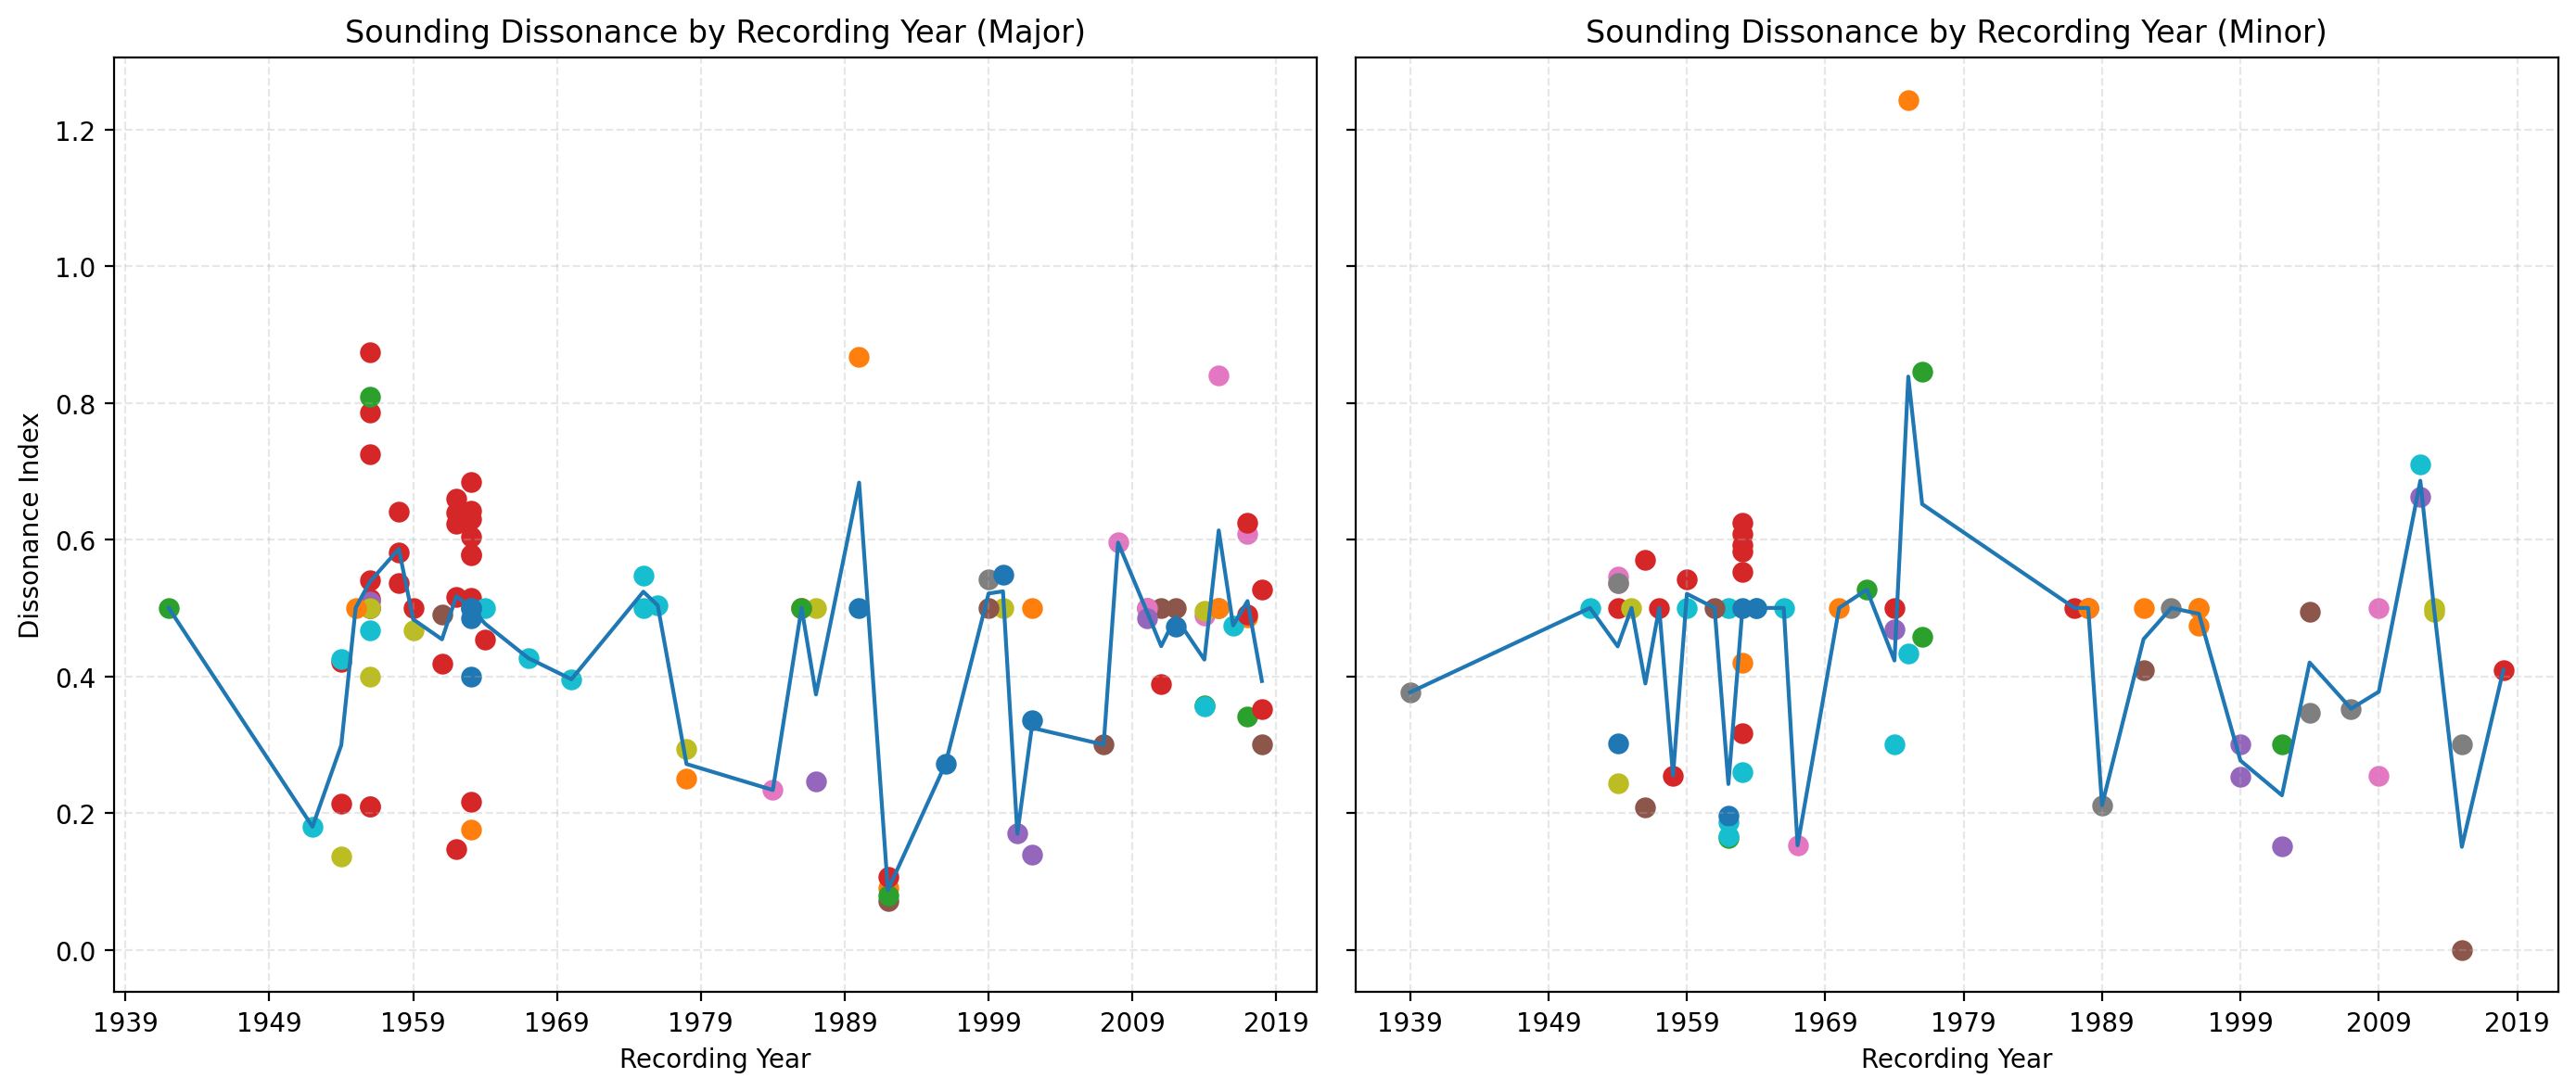

In [21]:
# Ensure recording_year is numeric
harmonies_major['recording_year'] = pd.to_numeric(harmonies_major['recording_year'], errors='coerce')
harmonies_minor['recording_year'] = pd.to_numeric(harmonies_minor['recording_year'], errors='coerce')

# Find combined min and max year to keep axes consistent
min_year = min(harmonies_major['recording_year'].min(), harmonies_minor['recording_year'].min())
max_year = max(harmonies_major['recording_year'].max(), harmonies_minor['recording_year'].max())

ticks = np.arange(min_year, max_year + 10, 10)

artists = np.unique(np.concatenate([harmonies_major['artist'].unique(), harmonies_minor['artist'].unique()]))
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot major
for i, artist in enumerate(artists):
    subset = harmonies_major[harmonies_major['artist'] == artist]
    axes[0].scatter(subset['recording_year'], subset['dissonance'],
                    label=artist, color=colors[i % len(colors)], s=50)

axes[0].plot(harmonies_major.groupby(by='recording_year', as_index=False)['dissonance'].mean()['recording_year'], 
             harmonies_major.groupby(by='recording_year', as_index=False)['dissonance'].mean()['dissonance'])
axes[0].set_title('Sounding Dissonance by Recording Year (Major)')
axes[0].set_xlabel('Recording Year')
axes[0].set_ylabel('Dissonance Index')
axes[0].set_xticks(ticks)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Plot minor
for i, artist in enumerate(artists):
    subset = harmonies_minor[harmonies_minor['artist'] == artist]
    axes[1].scatter(subset['recording_year'], subset['dissonance'],
                    label=artist, color=colors[i % len(colors)], s=50)

axes[1].plot(harmonies_minor.groupby(by='recording_year', as_index=False)['dissonance'].mean()['recording_year'], 
             harmonies_minor.groupby(by='recording_year', as_index=False)['dissonance'].mean()['dissonance'])
axes[1].set_title('Sounding Dissonance by Recording Year (Minor)')
axes[1].set_xlabel('Recording Year')
axes[1].set_xticks(ticks)
axes[1].grid(True, linestyle='--', alpha=0.3)


plt.tight_layout()
plt.savefig(f"../Results/SoundingDissonanceIndex")
plt.show()

## In-label + non chord tone dissonance

In [23]:
major_notes = g.load_notes(major_metadata) 
minor_notes = g.load_notes(minor_metadata) 

In [32]:
def combine_notes(row):
    ils = row['ILS']
    note_val = row['note']
    
    if isinstance(ils, list):
        return ils + [note_val]
    else:
        return [note_val]

def notes_to_dissonance(notes):
    pcs = []
    for n in notes:
        n = g.fix_flats(n)
        n_m21 = m21.note.Note(n)
        pcs.append(n_m21.pitch.pitchClass) 

    intervals, semitones = ia.get_intervals_semitones(pcs)
    return ia.semitones_to_dissonance(semitones)
        

major_notes_labels = major_notes.copy()
major_notes_labels['notes_comb'] = major_notes_labels.apply(combine_notes, axis=1)
major_notes_labels['dissonance'] = major_notes_labels['notes_comb'].apply(notes_to_dissonance)

minor_notes_labels = minor_notes.copy()
minor_notes_labels['notes_comb'] = minor_notes_labels.apply(combine_notes, axis=1)
minor_notes_labels['dissonance'] = minor_notes_labels['notes_comb'].apply(notes_to_dissonance)

In [34]:
major_notes_labels['dissonance'] = major_notes_labels['dissonance'] * major_notes_labels['duration']

identifier = ['artist', 'workTitle', 'recording_year']
major_notes_labels = major_notes_labels.groupby(by=identifier, as_index=False)[['dissonance', 'duration']].mean()
major_notes_labels['dissonance'] = major_notes_labels['dissonance'] / major_notes_labels['duration']

minor_notes_labels['dissonance'] = minor_notes_labels['dissonance'] * minor_notes_labels['duration']

identifier = ['artist', 'workTitle', 'recording_year']
minor_notes_labels = minor_notes_labels.groupby(by=identifier, as_index=False)[['dissonance', 'duration']].mean()
minor_notes_labels['dissonance'] = minor_notes_labels['dissonance'] / minor_notes_labels['duration']

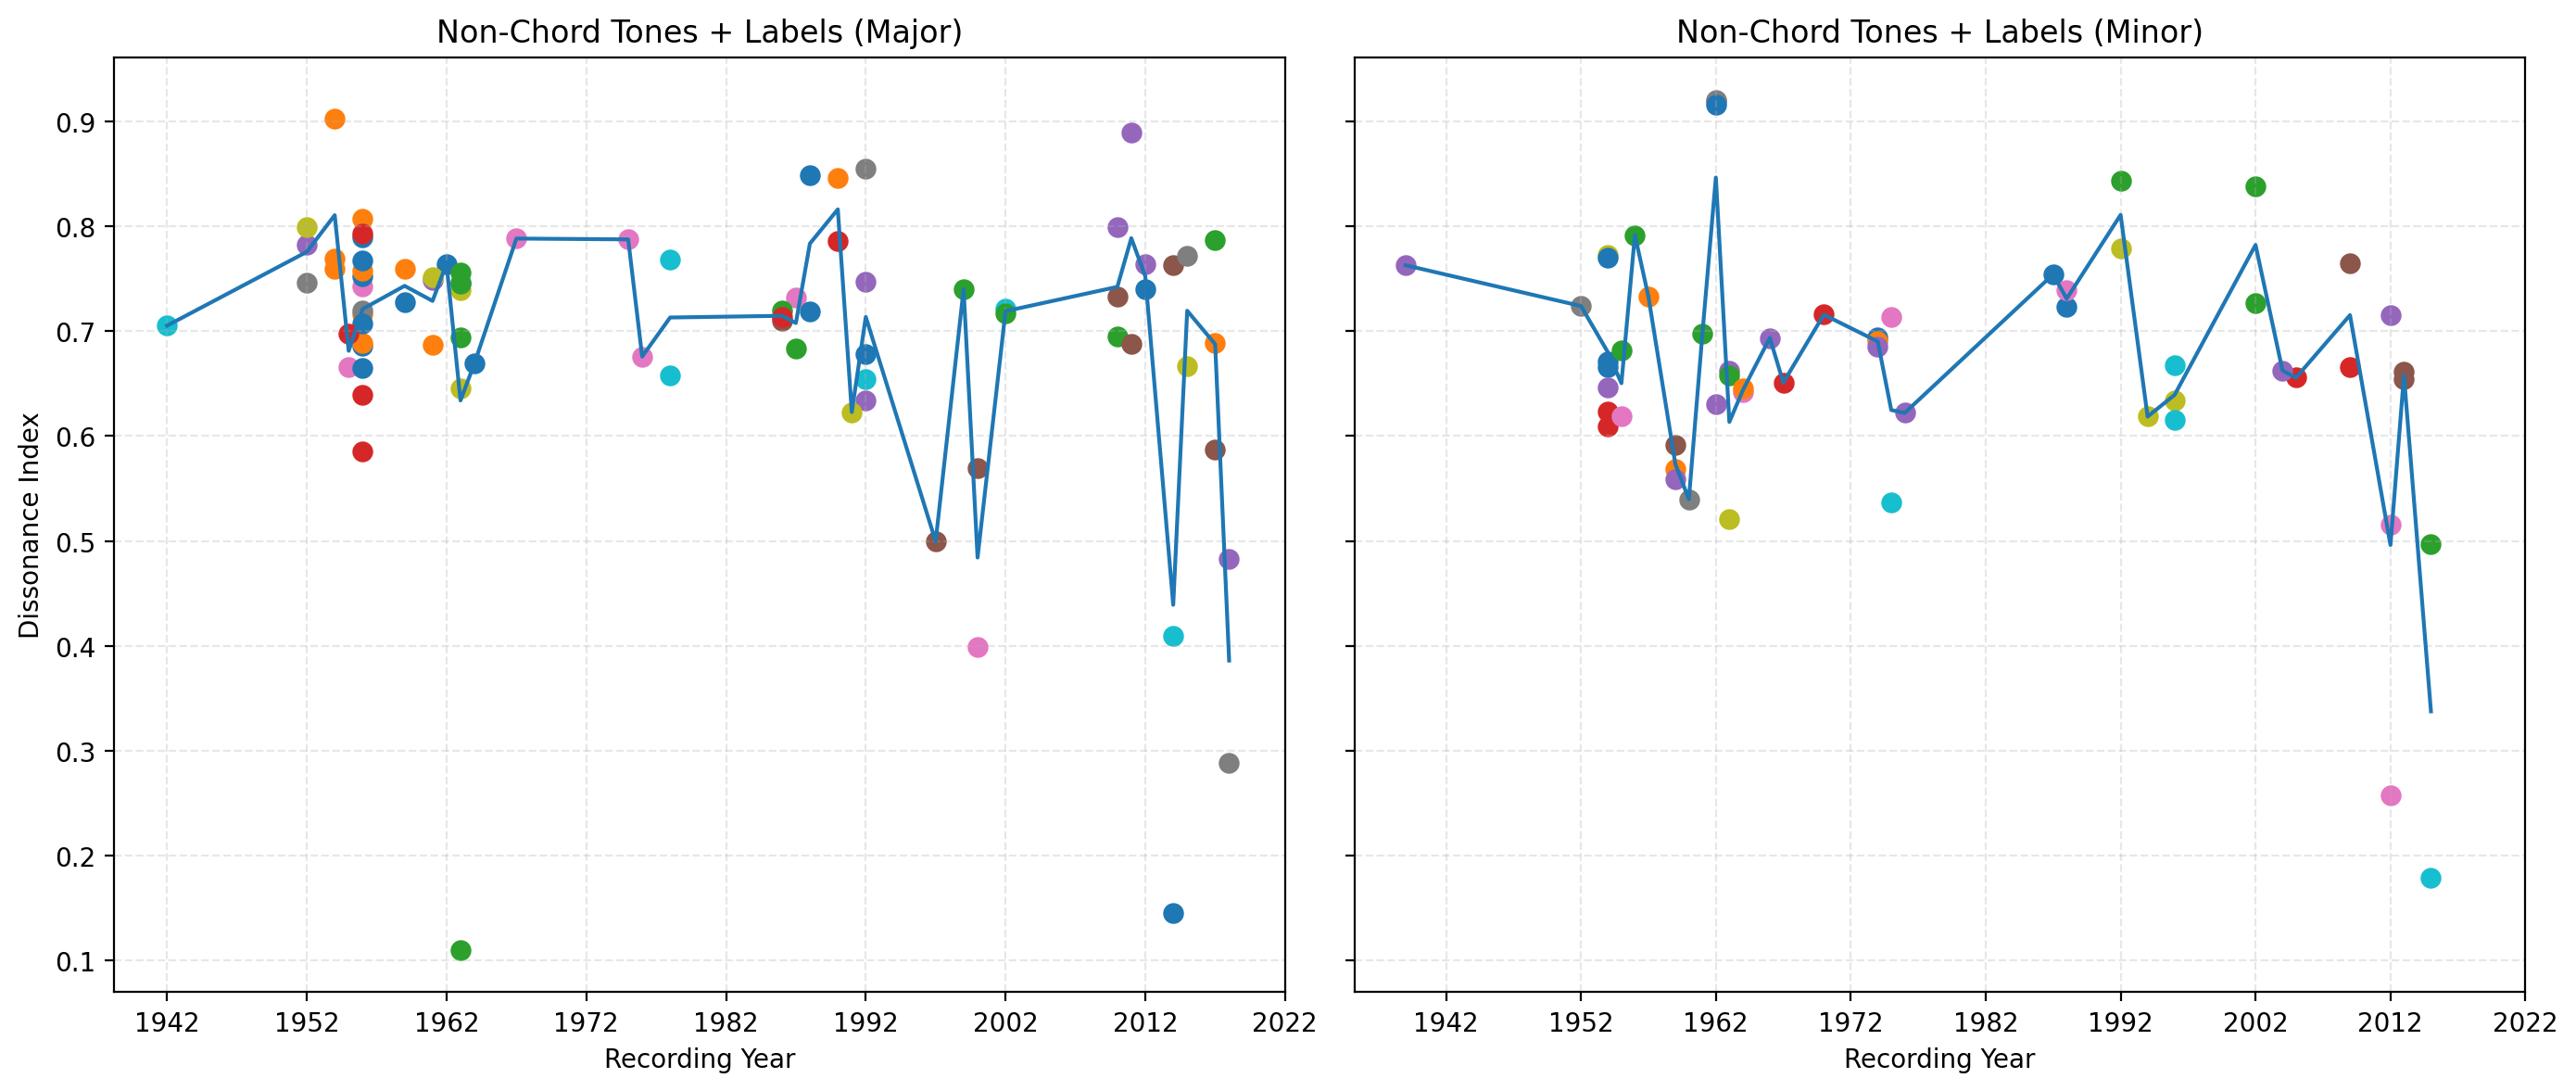

In [36]:
# Ensure recording_year is numeric
major_notes_labels['recording_year'] = pd.to_numeric(major_notes_labels['recording_year'], errors='coerce')
minor_notes_labels['recording_year'] = pd.to_numeric(minor_notes_labels['recording_year'], errors='coerce')

# Find combined min and max year to keep axes consistent
min_year = min(major_notes_labels['recording_year'].min(), major_notes_labels['recording_year'].min())
max_year = max(minor_notes_labels['recording_year'].max(), minor_notes_labels['recording_year'].max())

ticks = np.arange(min_year, max_year + 10, 10)

artists = np.unique(np.concatenate([major_notes_labels['artist'].unique(), minor_notes_labels['artist'].unique()]))
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot major
for i, artist in enumerate(artists):
    subset = major_notes_labels[major_notes_labels['artist'] == artist]
    axes[0].scatter(subset['recording_year'], subset['dissonance'],
                    label=artist, color=colors[i % len(colors)], s=50)

axes[0].plot(major_notes_labels.groupby(by='recording_year', as_index=False)['dissonance'].mean()['recording_year'], 
             major_notes_labels.groupby(by='recording_year', as_index=False)['dissonance'].mean()['dissonance'])
axes[0].set_title('Non-Chord Tones + Labels (Major)')
axes[0].set_xlabel('Recording Year')
axes[0].set_ylabel('Dissonance Index')
axes[0].set_xticks(ticks)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Plot minor
for i, artist in enumerate(artists):
    subset = minor_notes_labels[minor_notes_labels['artist'] == artist]
    axes[1].scatter(subset['recording_year'], subset['dissonance'],
                    label=artist, color=colors[i % len(colors)], s=50)

axes[1].plot(minor_notes_labels.groupby(by='recording_year', as_index=False)['dissonance'].mean()['recording_year'], 
             minor_notes_labels.groupby(by='recording_year', as_index=False)['dissonance'].mean()['dissonance'])
axes[1].set_title('Non-Chord Tones + Labels (Minor)')
axes[1].set_xlabel('Recording Year')
axes[1].set_xticks(ticks)
axes[1].grid(True, linestyle='--', alpha=0.3)


plt.tight_layout()
plt.savefig(f"../Results/NonChordTone+LabelDissonanceIndex")
plt.show()

## Non Chord Tones

In [79]:
major_notes['note'] = major_notes['note'].apply(g.fix_flats)
minor_notes['note'] = minor_notes['note'].apply(g.fix_flats)

In [118]:
import math
def in_ILS(note_name, ils_list):
    if isinstance(ils_list, float) and math.isnan(ils_list):
        return np.nan

    n = m21.note.Note(note_name)

    if n.name in ils_list:
        return 1
    else:
        return 0


major_notes['in_ILS?'] = major_notes.apply(lambda row: in_ILS(row['note'], row['ILS']), axis=1)
minor_notes['in_ILS?'] = minor_notes.apply(lambda row: in_ILS(row['note'], row['ILS']), axis=1)

In [144]:
major_notes_counts = major_notes.groupby('recording_year', as_index=False)[['in_ILS?']].sum()
major_total_notes = major_notes.groupby('recording_year').size().reset_index(name='total_notes')
major_notes_counts = major_notes_counts.merge(major_total_notes, on='recording_year', how='left')
major_notes_counts['percentage'] = 100 * major_notes_counts['in_ILS?'] / major_notes_counts['total_notes']

minor_notes_counts = minor_notes.groupby('recording_year', as_index=False)[['in_ILS?']].sum()
minor_total_notes = minor_notes.groupby('recording_year').size().reset_index(name='total_notes')
minor_notes_counts = minor_notes_counts.merge(minor_total_notes, on='recording_year', how='left')
minor_notes_counts['percentage'] = 100* minor_notes_counts['in_ILS?'] / minor_notes_counts['total_notes']

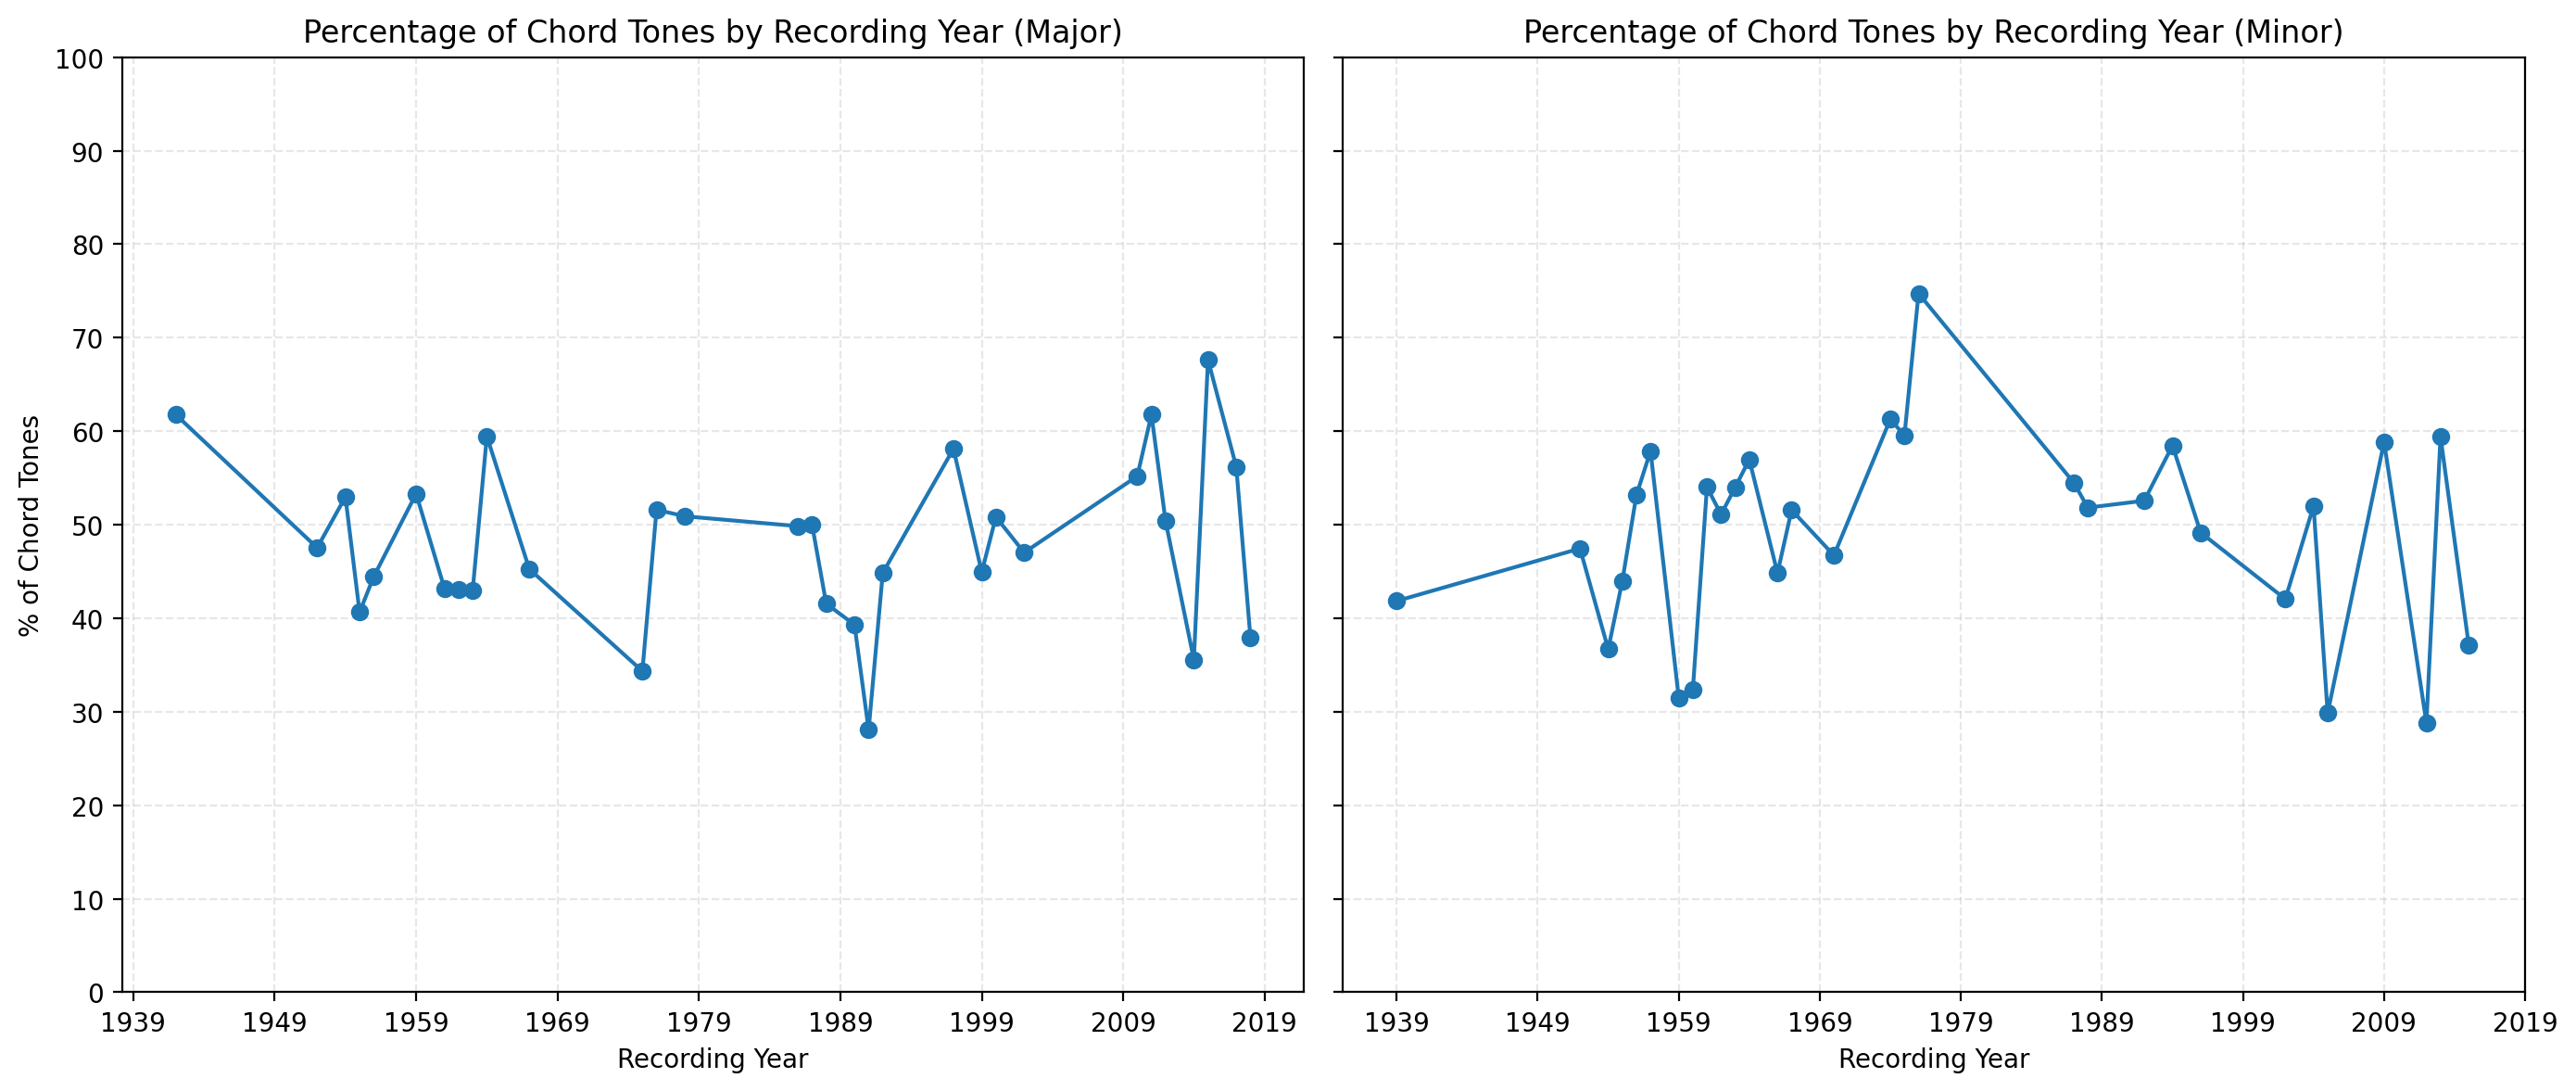

In [164]:
major_notes_counts['recording_year'] = pd.to_numeric(major_notes_counts['recording_year'], errors='coerce')
minor_notes_counts['recording_year'] = pd.to_numeric(minor_notes_counts['recording_year'], errors='coerce')
major_notes_counts = major_notes_counts.dropna(subset = ['recording_year'])
minor_notes_counts = minor_notes_counts.dropna(subset = ['recording_year'])
# Find combined min and max year to keep axes consistent
min_year = min(ILC_major['recording_year'].min(), ILC_minor['recording_year'].min())
max_year = max(ILC_major['recording_year'].max(), ILC_minor['recording_year'].max())

ticks = np.arange(min_year, max_year + 10, 10)

artists = np.unique(np.concatenate([ILC_major['artist'].unique(), ILC_minor['artist'].unique()]))
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plot major

axes[0].plot(major_notes_counts['recording_year'], major_notes_counts['percentage'], marker = 'o')

axes[0].set_title('Percentage of Chord Tones by Recording Year (Major)')
axes[0].set_xlabel('Recording Year')
axes[0].set_ylabel('% of Chord Tones')
axes[0].set_yticks(np.arange(0,100+10, 10))
axes[0].set_xticks(ticks)
axes[0].grid(True, linestyle='--', alpha=0.3)

# Plot minor
axes[1].plot(minor_notes_counts['recording_year'], minor_notes_counts['percentage'], marker = 'o')
axes[1].set_title('Percentage of Chord Tones by Recording Year (Minor)')
axes[1].set_xlabel('Recording Year')
axes[1].set_xticks(ticks)
axes[1].set_yticks(np.arange(0,100+10, 10))
axes[1].grid(True, linestyle='--', alpha=0.3)


plt.tight_layout()
plt.savefig(f"../Results/PercentageChordTones")
plt.show()